In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("netflix_customer_churn.csv")
df.head()


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [4]:
df.isna().sum()

categorical_vars = [
    "subscription_type", "gender", "region",
    "device", "payment_method", "favorite_genre"
]

for col in categorical_vars:
    df[col] = df[col].astype("category")

df["churned"] = df["churned"].astype(int)


In [5]:
model1 = smf.logit(
    "churned ~ watch_hours * subscription_type",
    data=df
).fit()
print(model1.summary())


Optimization terminated successfully.
         Current function value: 0.507804
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4994
Method:                           MLE   Df Model:                            5
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2674
Time:                        00:39:24   Log-Likelihood:                -2539.0
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     

In [6]:
model2 = smf.logit(
    "churned ~ watch_hours * device",
    data=df
).fit()
print(model2.summary())


Optimization terminated successfully.
         Current function value: 0.525290
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4990
Method:                           MLE   Df Model:                            9
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2421
Time:                        00:39:32   Log-Likelihood:                -2626.5
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        1.5272      0.130     11.734      0.000

In [7]:
model3 = smf.logit(
    "churned ~ watch_hours * payment_method",
    data=df
).fit()
print(model3.summary())


Optimization terminated successfully.
         Current function value: 0.511508
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4990
Method:                           MLE   Df Model:                            9
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2620
Time:                        00:39:39   Log-Likelihood:                -2557.5
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    1.3

In [8]:
model4 = smf.logit(
    "churned ~ watch_hours * age",
    data=df
).fit()
print(model4.summary())


Optimization terminated successfully.
         Current function value: 0.525812
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4996
Method:                           MLE   Df Model:                            3
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2414
Time:                        00:39:46   Log-Likelihood:                -2629.1
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.4923      0.169      8.852      0.000       1.162       1.823
watch_hours   

In [9]:
model5 = smf.logit(
    "churned ~ avg_watch_time_per_day * subscription_type",
    data=df
).fit()
print(model5.summary())


Optimization terminated successfully.
         Current function value: 0.321145
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4994
Method:                           MLE   Df Model:                            5
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.5367
Time:                        00:39:56   Log-Likelihood:                -1605.7
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept              

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [10]:
model6 = smf.logit(
    """
    churned ~ watch_hours * subscription_type * device
    """,
    data=df
).fit()
print(model6.summary())


Optimization terminated successfully.
         Current function value: 0.506071
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4970
Method:                           MLE   Df Model:                           29
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2699
Time:                        00:40:02   Log-Likelihood:                -2530.4
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept   

In [11]:
model7 = smf.logit(
    """
    churned ~
        watch_hours * subscription_type +
        watch_hours * device +
        watch_hours * payment_method +
        watch_hours * age
    """,
    data=df
).fit()
print(model7.summary())


Optimization terminated successfully.
         Current function value: 0.490992
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4976
Method:                           MLE   Df Model:                           23
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.2916
Time:                        00:40:13   Log-Likelihood:                -2455.0
converged:                       True   LL-Null:                       -3465.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     

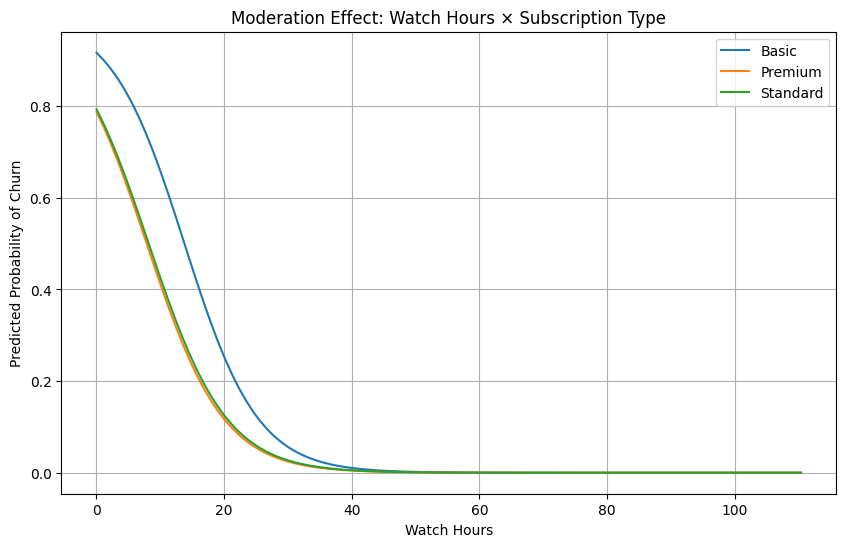

In [12]:
x = np.linspace(df.watch_hours.min(), df.watch_hours.max(), 100)
pred_df = pd.DataFrame({
    "watch_hours": np.tile(x, 3),
    "subscription_type": np.repeat(df.subscription_type.cat.categories, 100),
})

pred_df["pred"] = model1.predict(pred_df)

plt.figure(figsize=(10,6))
for s in df.subscription_type.cat.categories:
    plt.plot(
        pred_df[pred_df.subscription_type == s]["watch_hours"],
        pred_df[pred_df.subscription_type == s]["pred"],
        label=s
    )

plt.xlabel("Watch Hours")
plt.ylabel("Predicted Probability of Churn")
plt.title("Moderation Effect: Watch Hours × Subscription Type")
plt.legend()
plt.grid(True)
plt.show()


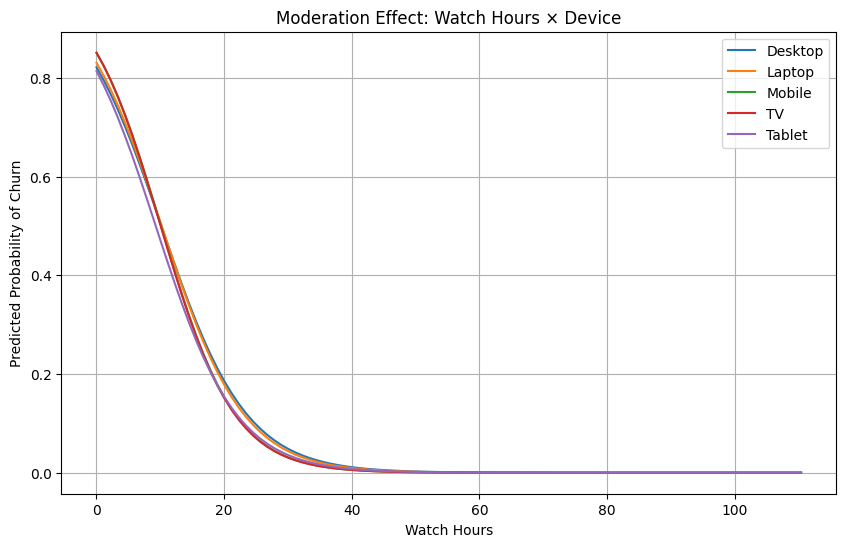

In [13]:
x = np.linspace(df.watch_hours.min(), df.watch_hours.max(), 100)
pred_df = pd.DataFrame({
    "watch_hours": np.tile(x, len(df.device.cat.categories)),
    "device": np.repeat(df.device.cat.categories, 100)
})

pred_df["pred"] = model2.predict(pred_df)

plt.figure(figsize=(10,6))
for d in df.device.cat.categories:
    plt.plot(
        pred_df[pred_df.device == d]["watch_hours"],
        pred_df[pred_df.device == d]["pred"],
        label=d
    )

plt.xlabel("Watch Hours")
plt.ylabel("Predicted Probability of Churn")
plt.title("Moderation Effect: Watch Hours × Device")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-2249866504.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heat_df = df.groupby(["watch_bin", "login_bin"]).apply(


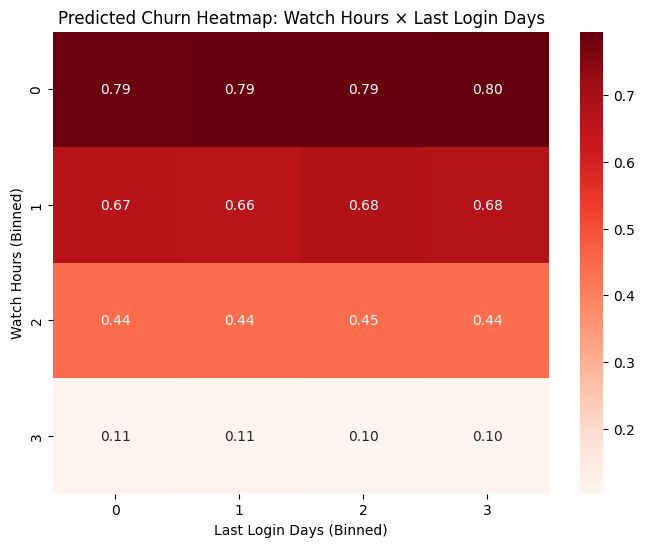

In [18]:
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

watch_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
login_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

df["watch_bin"] = watch_bins.fit_transform(df[["watch_hours"]]).astype(int)
df["login_bin"] = login_bins.fit_transform(df[["last_login_days"]]).astype(int)

heat_df = df.groupby(["watch_bin", "login_bin"]).apply(
    lambda x: model.predict(x).mean()
).reset_index(name="predicted_churn")

heat_matrix = heat_df.pivot(index="watch_bin", columns="login_bin", values="predicted_churn")

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(heat_matrix, annot=True, fmt=".2f", cmap="Reds")
plt.xlabel("Last Login Days (Binned)")
plt.ylabel("Watch Hours (Binned)")
plt.title("Predicted Churn Heatmap: Watch Hours × Last Login Days")
plt.show()


/tmp/ipython-input-1047185452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="churned", y="last_login_days", palette="Set2")


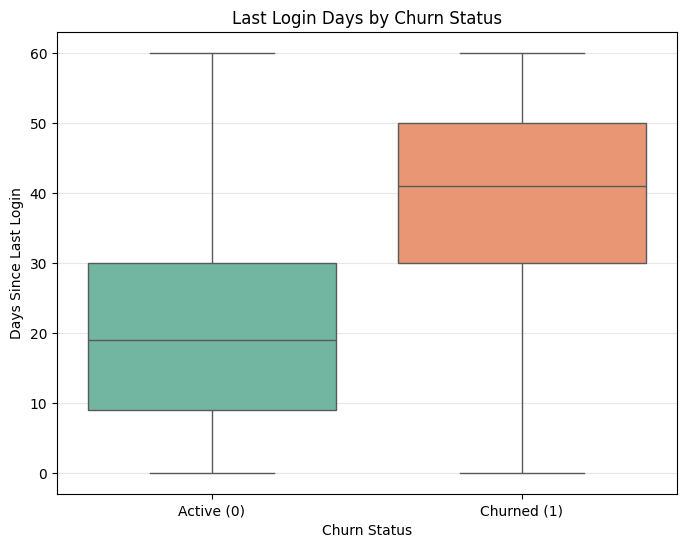

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="churned", y="last_login_days", palette="Set2")

plt.xticks([0,1], ["Active (0)", "Churned (1)"])
plt.xlabel("Churn Status")
plt.ylabel("Days Since Last Login")
plt.title("Last Login Days by Churn Status")
plt.grid(axis='y', alpha=0.3)

plt.show()


/tmp/ipython-input-1500587068.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rates = df.groupby("subscription_type")["churned"].mean().sort_values()


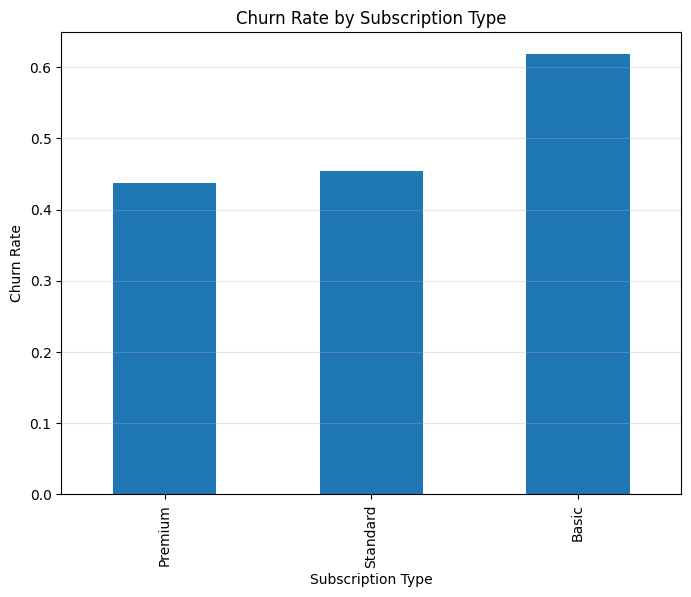

In [20]:
churn_rates = df.groupby("subscription_type")["churned"].mean().sort_values()

plt.figure(figsize=(8,6))
churn_rates.plot(kind="bar")

plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Subscription Type")
plt.grid(axis='y', alpha=0.3)

plt.show()
